In [2]:
import os
import numpy as np
import cv2
from PIL import Image
from matplotlib import pyplot as plt

In [3]:
pmatrix_new = np.load('./data/pmatrix_new.npy')
new_w = int(np.load('./data/new_w.npy'))
new_h = int(np.load('./data/new_h.npy'))

coord [83311700, 83317000, 83322400, 83327200, 83332100, 83336600, 83340800, 83345400, 83350200, 83354700, 83359800, 83365100, 83370700, 83376500, 83383000, 83390100, 83397400, 83404400, 83411400, 83418400, 83427200, 83437700, 83447600, 83457200, 83465900, 83474500, 83482700, 83490600, 83498100, 83505000, 83511600, 83517200, 83522500, 83527600, 83532900, 83538700, 83545300, 83552800, 83561100, 83568100, 83575200, 83582000, 83588800, 83596400, 83604500, 83614200, 83622300, 83628900, 83635100, 83640800, 83646200, 83651900, 83657200, 83662400, 83667500, 83672600, 83677500, 83682600, 83688000, 83693400, 83699400, 83705200, 83711300, 83717400, 83723400, 83729800, 83736200, 83742400, 83748700, 83754600, 83761200, 83769100, 83776000, 83785200, 83795900, 83805100, 83814000, 83823500, 83832700, 83841200, 83849400, 83856600, 83864000, 83871300, 83879100, 83887900, 83895700, 83902700, 83909100, 83916000, 83921900, 83929400, 83937500, 83947500, 83959900, 83972700, 83985200, 83998700, 84014600, 840

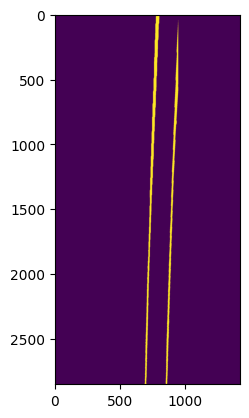

In [53]:
src = r'./data/4'
img_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.jpg')]
msk_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.npy')]

import re
coord = []

msk_fs = msk_fs  # временно для тестов

for f in msk_fs:
    match = re.search(r'(\d+\.\d)', f)
    if match:
        result = match.group(1)
        coord.append(int(float(result)*1000))  # переводим координаты в мм

print('coord', coord)


def load_warp(mask_path):
    mask = np.load(mask_path)
    mask = np.array(mask, dtype=np.uint8)
    res = cv2.warpPerspective(mask, pmatrix_new, (new_w, new_h))
    res[:, :int(res.shape[1]/3)] = 0
    res[:, -int(res.shape[1]/3):] = 0
    return res

def resize(arr):
    # scale = 1000 / max(arr.shape)
    scale = 0.1
    display_res = cv2.resize(arr, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    return display_res

# fig, ax = plt.subplots()

# # mask_pr = load_warp(r"D:\Projects\perspective\data\3\080843.789.jpg")
mask_pr = load_warp(msk_fs[20])

print(mask_pr.shape)
plt.imshow(resize(mask_pr))

In [5]:
def bend(mask, shift=200):
    h, w = mask.shape[:2]
    # Исходные углы (порядок: верх-лево, верх-право, низ-право, низ-лево)
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])

    dst = np.float32([
        [shift, 0],        # верх-лево → вправо
        [w + shift, 0],    # верх-право → влево
        [w, h],            # низ-право — на месте
        [0, h]             # низ-лево — на месте
    ])
    # Матрица и преобразование
    M = cv2.getPerspectiveTransform(src, dst)
    result = cv2.warpPerspective(mask, M, (w, h))
    return result

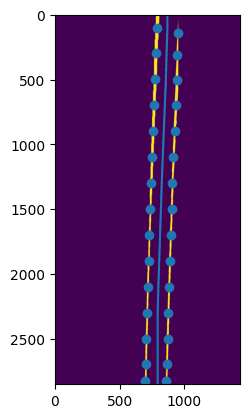

In [6]:
def find_rail_dots(mask, step=2000):
    # далее можно сократить расчеты
    """[Y, X] для рельсов, [y_centr, x_centr] для центр точек"""
    centroids = []

    height = mask.shape[0]
    num_steps = int(np.ceil(height / step))

    for i in range(num_steps):
        st = i * step
        en = np.min((st + step, height))
        contours, _ = cv2.findContours(mask[st:en, :], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        for contour in contours:
            M = cv2.moments(contour)
            if M["m00"] != 0:  # Проверяем, чтобы избежать деления на ноль
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                centroids.append((cx, cy+st))

    X = np.array(centroids)[:, 0]
    Y = np.array(centroids)[:, 1]
    diff = np.diff(Y)
    # ищет пары близких центроидов (где вертикальное расстояние меньше 3 пикселей) и вычисляет для них среднюю точку по X

    mid_p = []
    for i, v in enumerate(diff):
        if v < 3:
            mid_x = int((X[i] + X[i+1]) / 2)
            mid_y = int((Y[i] + Y[i+1]) / 2)
            mid_p.append([mid_x, mid_y])

    mid_p = np.array(mid_p) # точки между центроидами
    # Интеролировать серединки для всех У
    y_centr = np.arange(mask.shape[0])
    x_centr = np.interp(y_centr, mid_p[:, 1], mid_p[:, 0])

    return np.array([Y, X]), np.array([y_centr, x_centr])


YX, yx_centr = find_rail_dots(mask_pr)

plt.imshow(resize(mask_pr))
plt.scatter(YX[1, :]//10, YX[0, :]//10)
plt.plot(yx_centr[1, :]//10, yx_centr[0, :]//10)
plt.margins(0, 0)


In [7]:
# поворот

def rotate(rect, angle, point):
    """angle в радианах
       point точка вокруг которой повернуть
       полож знач пов против часовой
    """
    c, s = np.cos(angle), np.sin(angle)
    rotation_matrix = np.array([
        [c, -s],
        [s,  c]
    ])

    shifted_rect = rect - point
    rotated_rectangle = (rotation_matrix @ shifted_rect.T).T + point
    return rotated_rectangle


0.19739555984988075


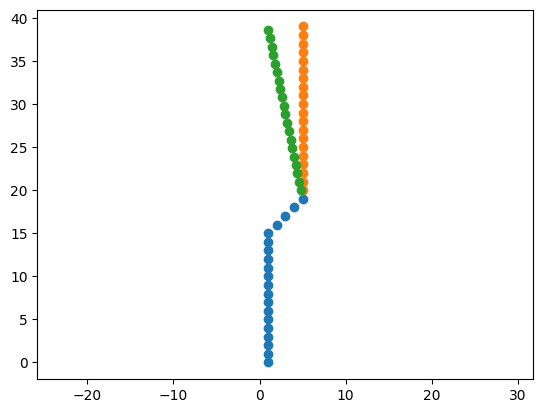

In [992]:
a1 = np.array([np.ones(20), np.arange(20)])
a1[0, 15:] += np.arange(5)



a2 = np.array([np.ones(20), np.arange(20, 40)])
a2[0, :] += 4

p2 = a2.T[-1]
p1 = a1.T[0]
p0 = [1, 19]

dx = p2[0] - p0[0]
dy = p2[1] - p0[1]

angle = np.arctan2(dx, dy)

print(angle)

a3 = rotate(a2.T, 0.2, a1.T[-1]).T  # повернуть на минус angle

plt.scatter(a1[0, :], a1[1, :])
plt.scatter(a2[0, :], a2[1, :])
plt.scatter(a3[0, :], a3[1, :])
plt.axis('equal');

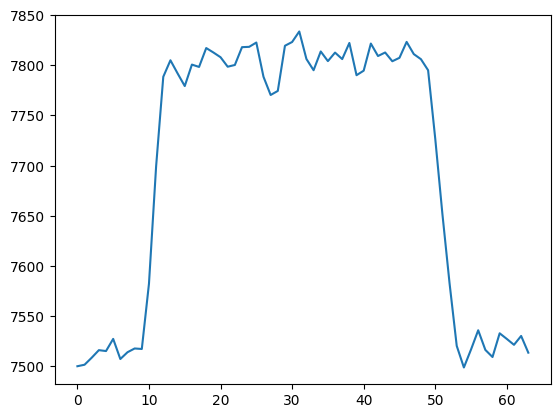

In [553]:
plt.plot(niz_all[1:])

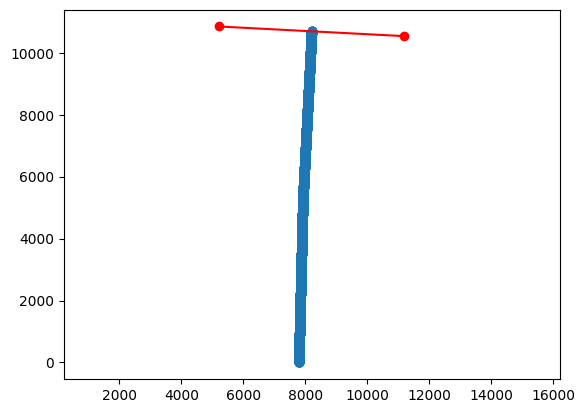

In [830]:
p1, p2 = yx_centr[-1][::-1], yx_centr[0][::-1]
# 2. Расчет направляющего вектора линии
v = p2 - p1
# 3. Нахождение перпендикулярного вектора (поворот на 90 градусов)
# Для вектора (x, y) перпендикуляр равен (-y, x)
v_perp = np.array([-v[1], v[0]])
length = 3000.0
v_perp_normalized = v_perp / np.linalg.norm(v_perp) * length
p3 = p2 + v_perp_normalized
p4 = p2 - v_perp_normalized

dx = p4[0] - p3[0]
dy = p4[1] - p3[1]
(np.arctan2(dy, dx))

plt.scatter(Array[:, 1], Array[:, 0])
plt.plot([p3[0], p4[0]], [p3[1], p4[1]], "r-o")
plt.axis('equal')
plt.show()

angle 0.1973955598498806      11


(np.float64(4.764083770219964),
 np.float64(11.235916229780036),
 np.float64(-0.5294174202707276),
 np.float64(11.117765825685279))

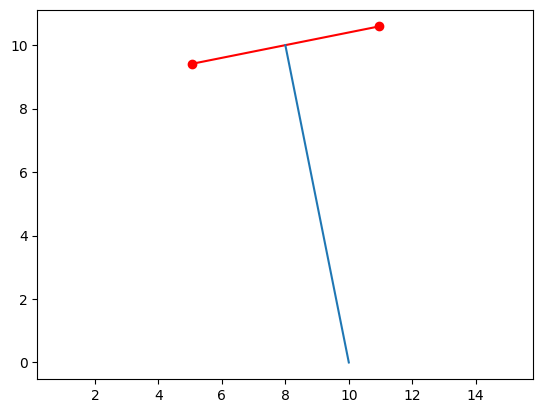

In [856]:
p1, p2 = np.array([10, 0]), np.array([8, 10])

line = np.linspace(p1, p2, 20)

v = p2 - p1
v_perp = np.array([-v[1], v[0]])
length = 3.0
v_perp_normalized = v_perp / np.linalg.norm(v_perp) * length
p3 = p2 + v_perp_normalized
p4 = p2 - v_perp_normalized

dx = p4[0] - p3[0]
dy = p4[1] - p3[1]
angle = np.arctan2(dy, dx)
print('angle', angle, '    ', np.int16(np.degrees(angle)))

plt.plot([p3[0], p4[0]], [p3[1], p4[1]], "r-o")
plt.plot(line[:, 0], line[:, 1])
plt.axis('equal')

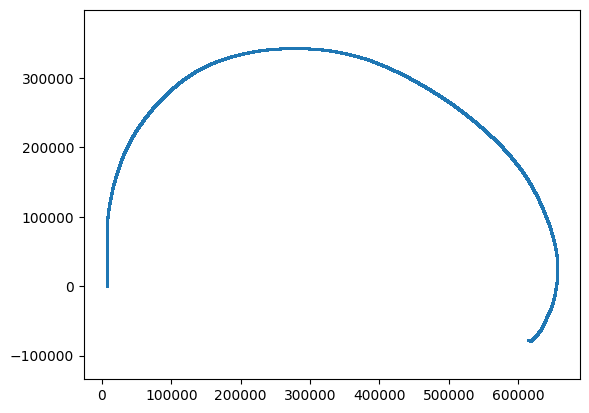

In [864]:
"""
поворачивает текущую картинку на угол наклона, но похоже это не то
смещает по Х и по У
"""
# yx_centr низ [-1], верх [0]
Array = np.zeros((1, 2))
angle_all = np.zeros((1))

niz_all = np.zeros((1, 1))
verx_all = np.zeros((1, 1))

x_norm = 7513. # (mask.shape[1] // 2) + 379

x_test = 0

angle = 0
coef = 0
shift = 0
for i, (m_f, c) in enumerate(zip(msk_fs[0:-1], coord[0:-1])):  # 0:-1 0:2 13:14 20:22 20:32 29:32
    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-(coord[i+1] - coord[i]): mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)
    # plt.imshow(resize(mask))
    # plt.plot(yx_centr[1, :]//10, yx_centr[0, :]//10)
    # plt.axvline((mask.shape[1] // 20)+38, c='g')
    # plt.show()

    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================
    # для первой итерации
    if i == 0:
        pass
    else:
        # смещение по У
        yx_centr[:, 0] += coef

        # для поворот
        b0 = yx_centr[-1][::-1]  # xy
        _b0 = [b0[0], yx_centr[0, 0]]  # проекция b0 на верхн грани
        b = yx_centr[0][::-1]  # xy

        dy = _b0[1] - b0[1]
        dx = b[0] - b0[0]

        _angle = np.arctan2(dx, dy)
        angle += _angle  # накопить угол

        # смещение по Х
        # сдвинуть центр в точку, где она находилась в предыдущ кадре
        shift = a - yx_centr[-1, 1]
        yx_centr[:, 1] += shift
    # для поворота
    yx_centr = rotate(yx_centr[:, [1, 0]], -angle, yx_centr[-1, [1, 0]])[:, [1, 0]]
    # обновл коорд Y на пройденный путь
    coef += yx_centr[0, 0] - yx_centr[-1, 0]  # shape тут не подходит, т.к. не измен после поворота

    # для смещения по Х
    a = yx_centr[0, 1]


    # print('пройденное', np.int32(coef))

    Array = np.vstack((Array, yx_centr))
    angle_all = np.vstack((angle_all, angle))
Array = Array[1:, :]  # убир перв строка, кот 0 0

plt.scatter(Array[:, 1], Array[:, 0], s=1)
plt.axis('equal')
plt.show()


In [ ]:
plt.plot(angle_all)

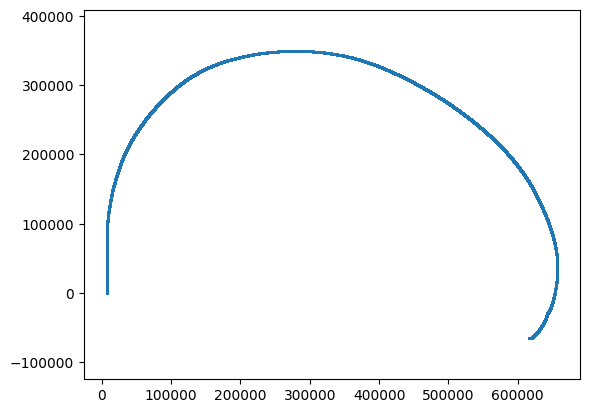

In [1029]:
"""
к верхней точке текущего проводит перепендикуляр, на этот угол поворачивает след кадр,
"""
# yx_centr низ [-1], верх [0]
Array = np.zeros((1, 2))

angle_all = np.zeros((1))

x_test = 0

angle = 0
coef = 0
shift = 0
for i, (m_f, c) in enumerate(zip(msk_fs[0:-1], coord[0:-1])):  # 0:-1 0:2 13:14 20:22 20:32 29:32
    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-(coord[i+1] - coord[i]): mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)
    # plt.imshow(resize(mask))
    # plt.plot(yx_centr[:, 1]//10, yx_centr[:, 0]//10)
    # plt.axvline((mask.shape[1] // 20)+38, c='g')
    # plt.show()

    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================
    # для первой итерации
    if i == 0:
        pass
    else:
        # смещение по X
        shift = a - yx_centr[-1, 1]
        yx_centr[:, 1] += shift

    # смещение по У
    yx_centr[:, 0] += coef


    if not angle:
        pass
    else:
        yx_centr = rotate(yx_centr[:, [1, 0]], angle, yx_centr[-1, [1, 0]])[:, [1, 0]]

    p1, p2 = yx_centr[-1][::-1], yx_centr[0][::-1]
    p1, p2
    # 2. Расчет направляющего вектора линии
    v = p2 - p1
    # 3. Нахождение перпендикулярного вектора (поворот на 90 градусов)
    # Для вектора (x, y) перпендикуляр равен (-y, x)
    v_perp = np.array([-v[1], v[0]])
    length = 3000.0
    v_perp_normalized = v_perp / np.linalg.norm(v_perp) * length
    p3 = p2 + v_perp_normalized
    p4 = p2 - v_perp_normalized
    # print(p3[0] - p4[0])

    dx = p4[0] - p3[0]
    dy = p4[1] - p3[1]

    angle = np.arctan2(dy, dx)

    # обновл коорд Y на пройденный путь
    coef += yx_centr[0, 0] - yx_centr[-1, 0]  # shape тут не подходит, т.к. не измен после поворота

    # для смещения по Х
    a = yx_centr[0, 1]

    # print('пройденное', np.int32(coef))


    Array = np.vstack((Array, yx_centr))
    angle_all = np.vstack((angle_all, angle))
Array = Array[1:, :]  # убир перв строка, кот 0 0
angle_all = angle_all[1:, :]

plt.scatter(Array[:, 1], Array[:, 0], s=1)
plt.axis('equal')
plt.show()


In [ ]:
plt.plot(angle_all[:])

In [892]:
data = np.load(r"\\10.3.3.100\d\temp\Для Андрея\Для плана по обзорным камерам\dc_x_y_z.npy")
data.shape

(261279, 4)

(np.float64(2854380.2303763237),
 np.float64(2854843.9019218097),
 np.float64(2198271.0018632105),
 np.float64(2199535.3959145993))

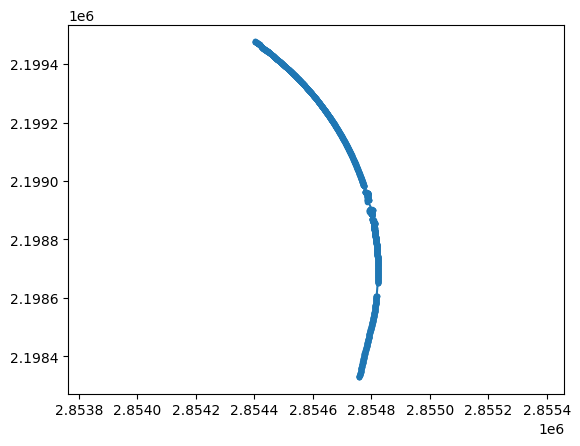

In [895]:
st, en = np.searchsorted(data[:, 0], [9618.434, 10999.719])
plt.plot(data[st:en, 1], data[st:en, 2], marker='.')
plt.axis('equal')

(np.float64(2839625.2200178425),
 np.float64(2855596.0697558615),
 np.float64(2184891.017169716),
 np.float64(2203601.170179997))

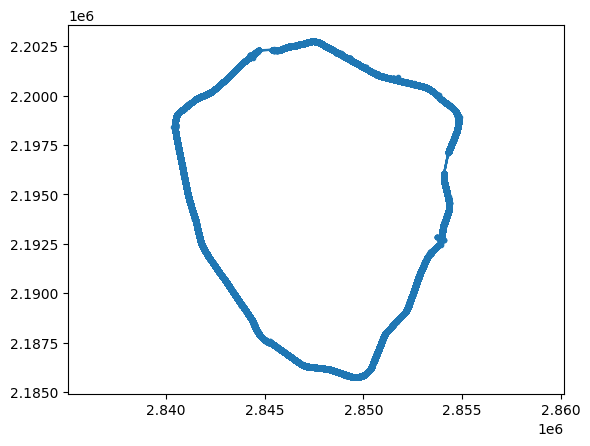

In [894]:
plt.plot(data[:, 1], data[:, 2], marker='.')
plt.axis('equal')

In [ ]:
slope = abs(dx) / dy if dy > 0 else 999

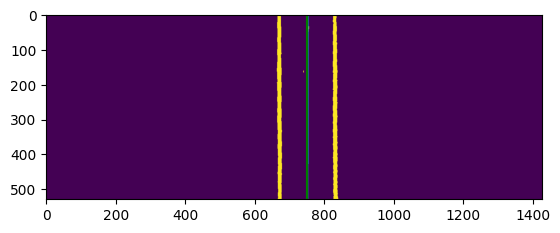

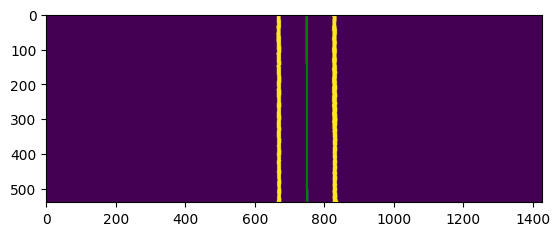

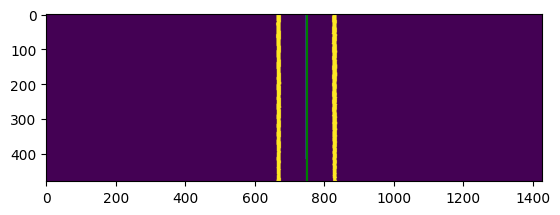

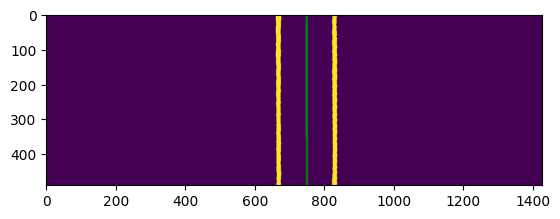

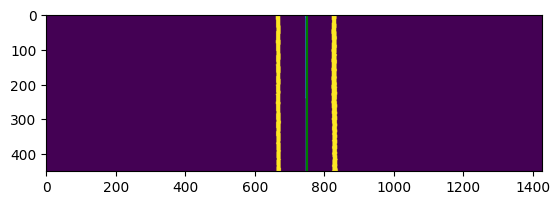

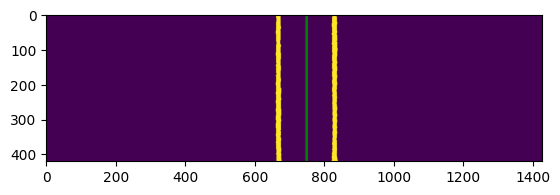

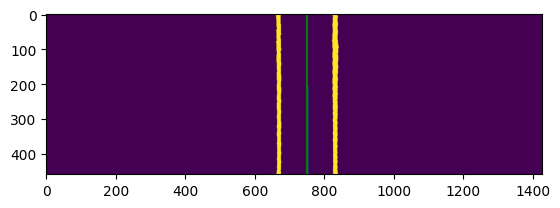

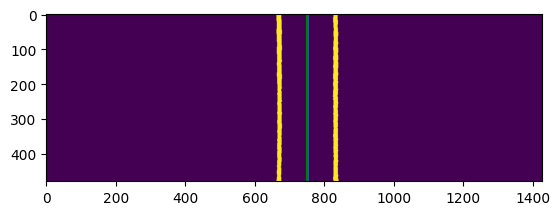

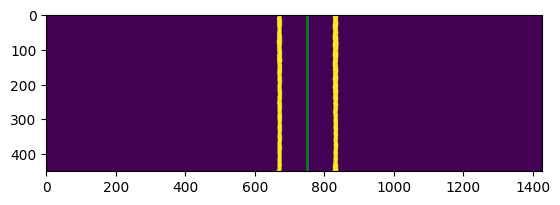

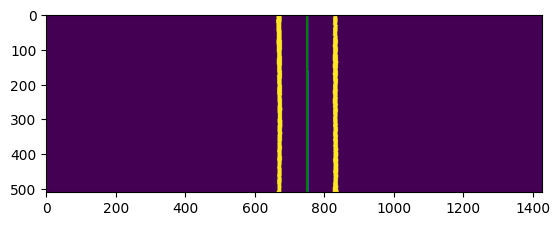

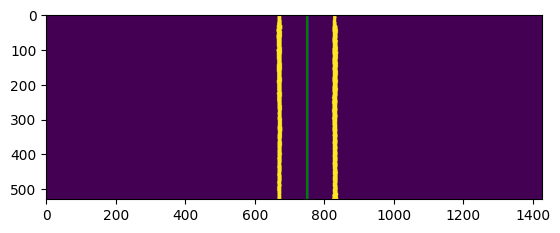

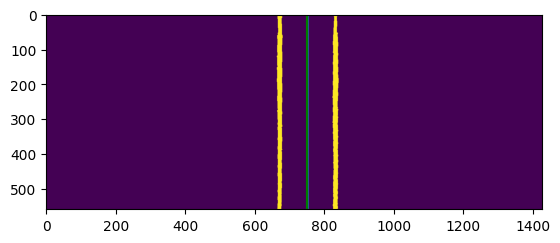

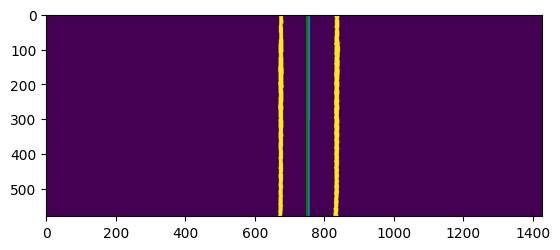

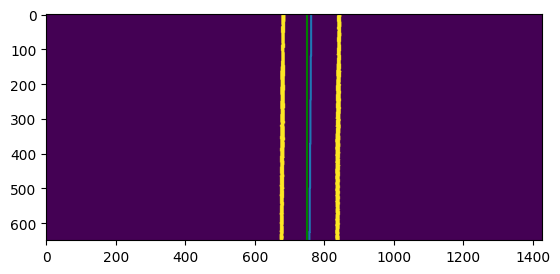

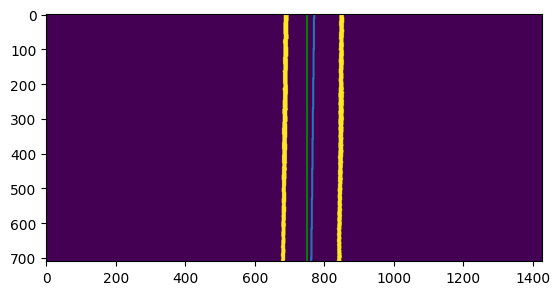

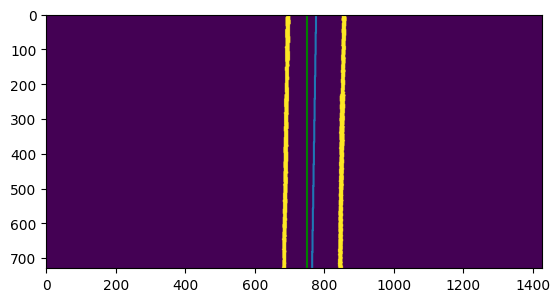

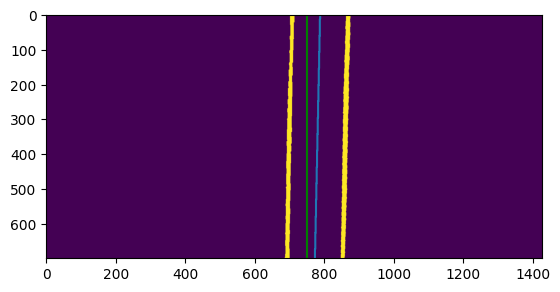

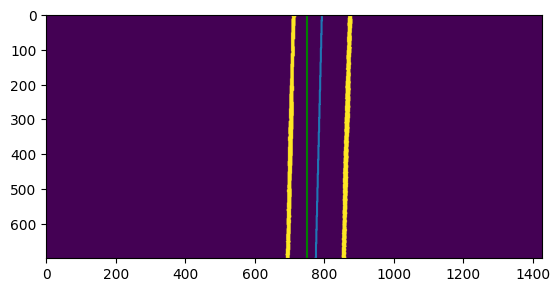

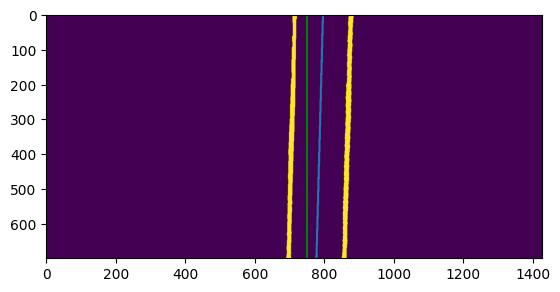

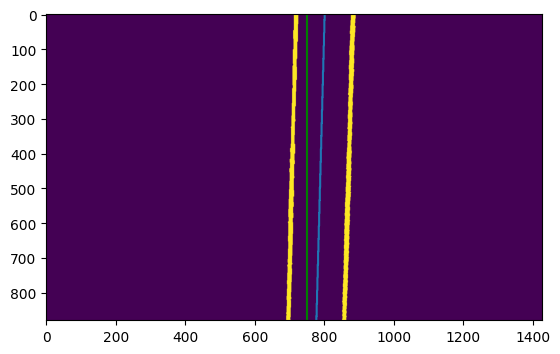

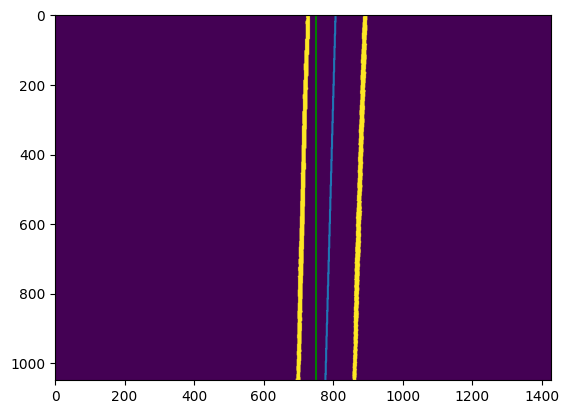

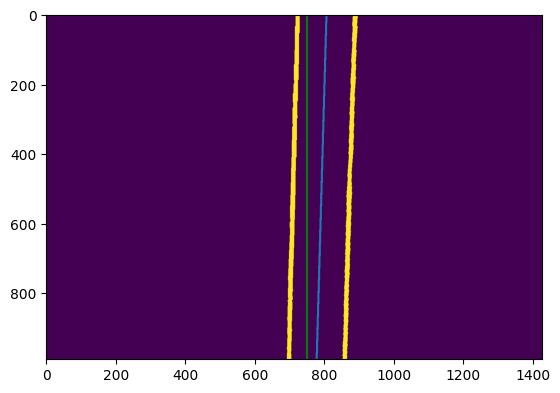

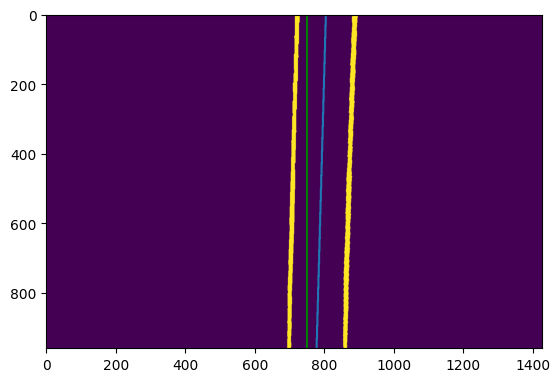

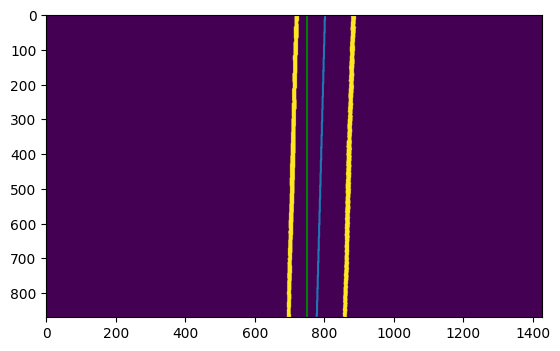

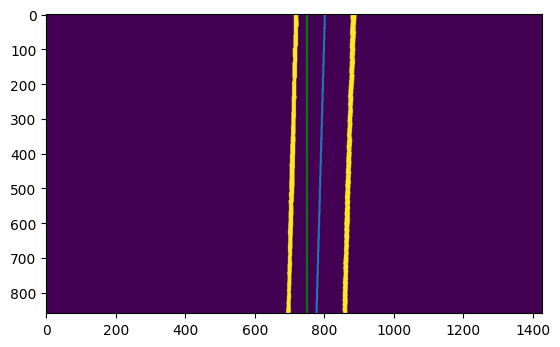

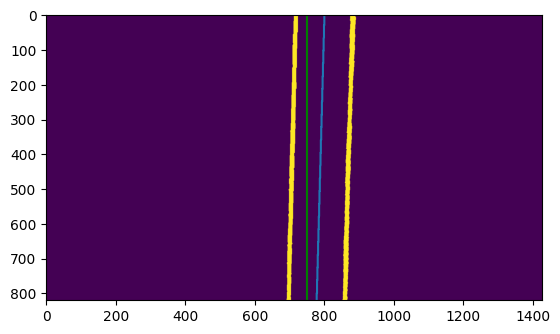

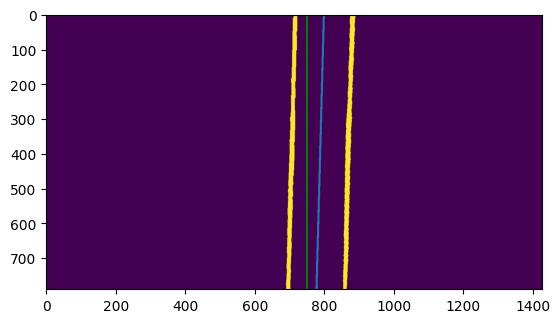

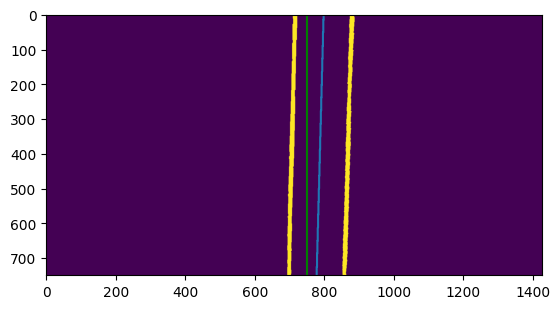

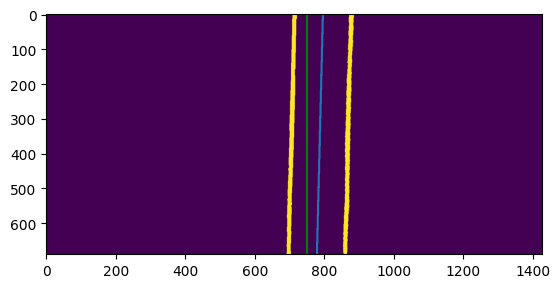

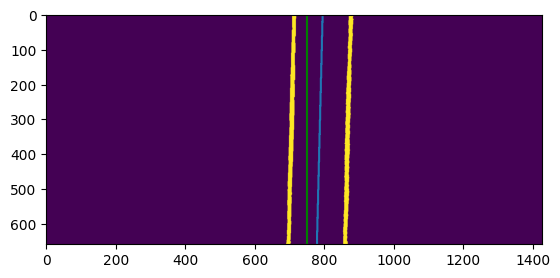

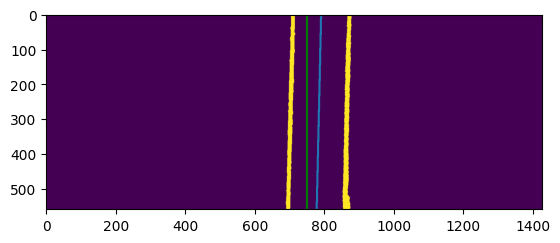

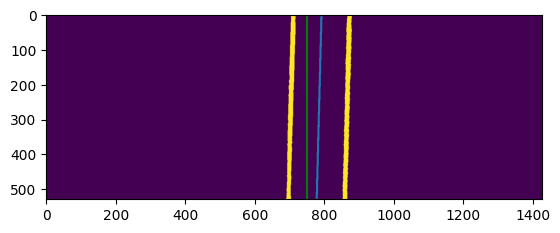

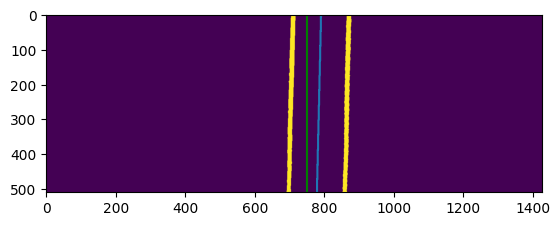

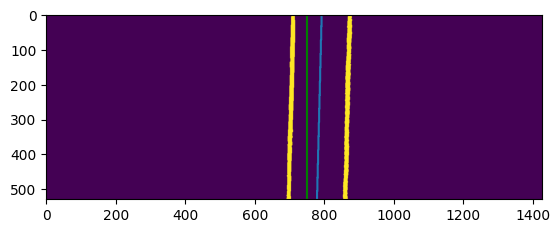

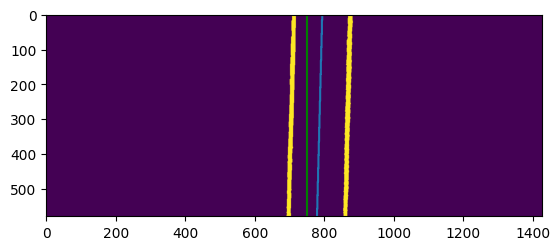

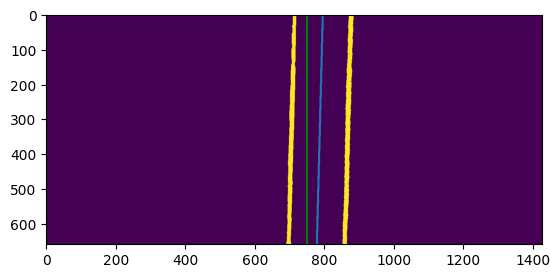

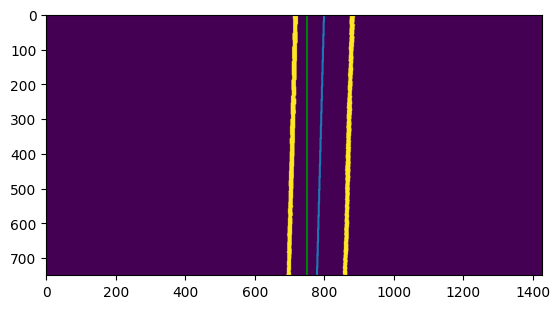

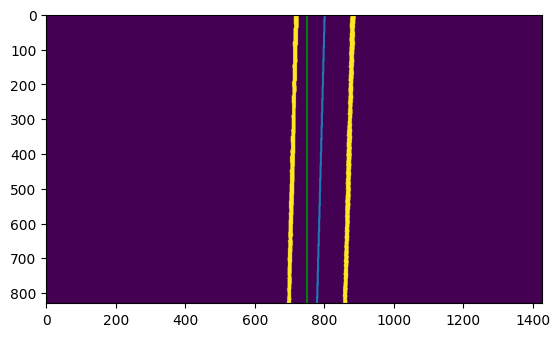

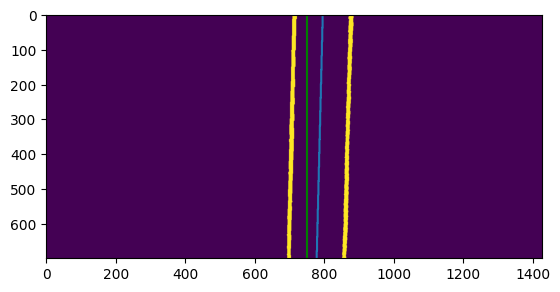

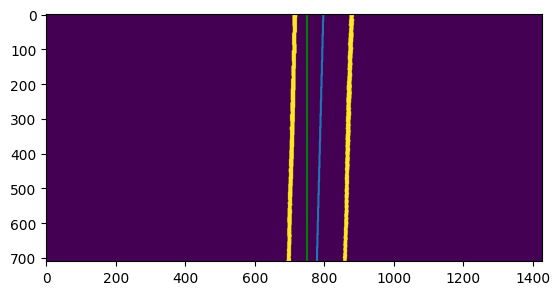

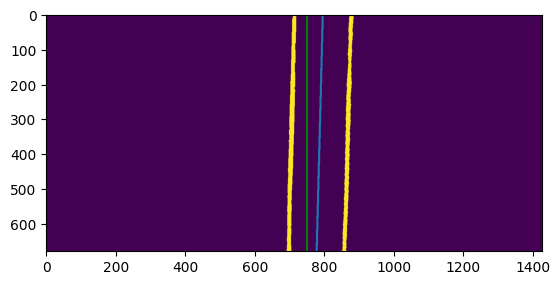

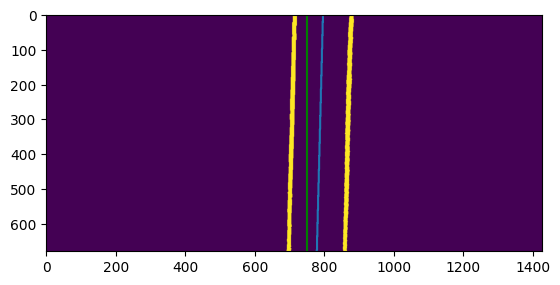

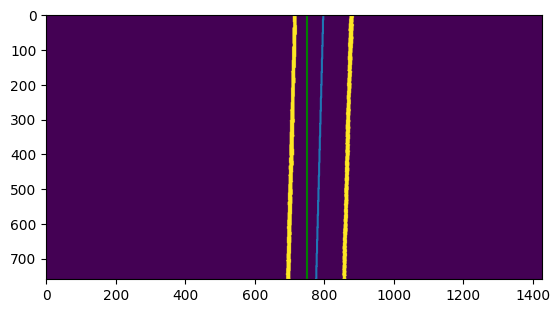

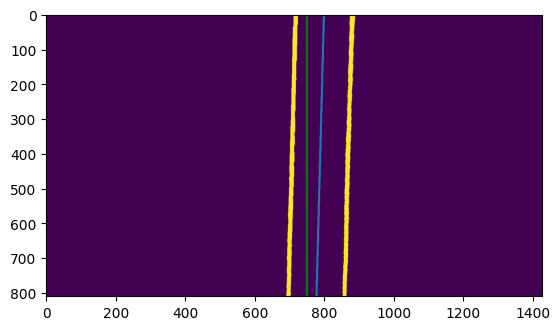

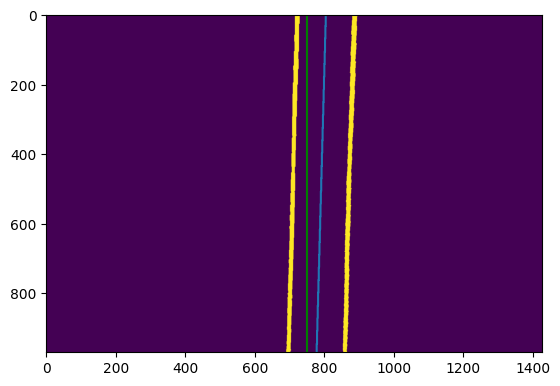

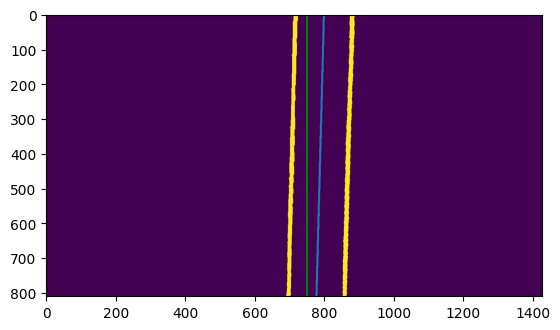

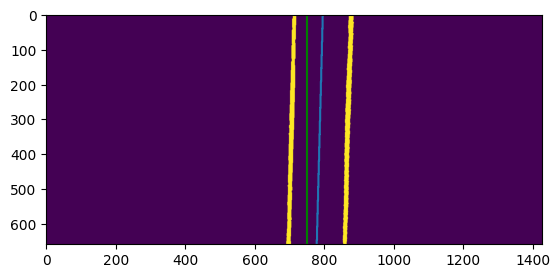

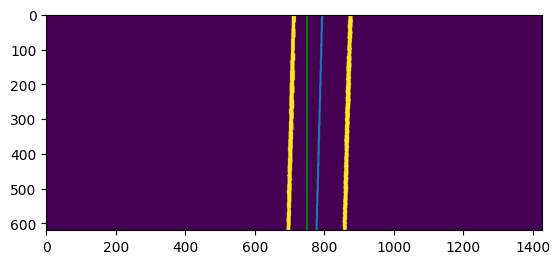

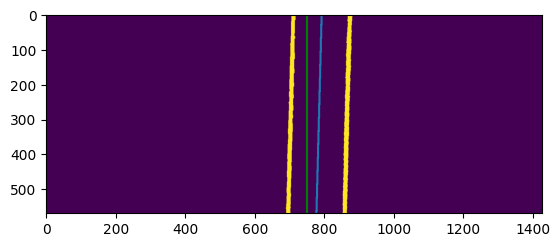

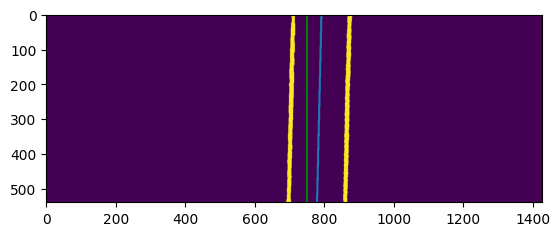

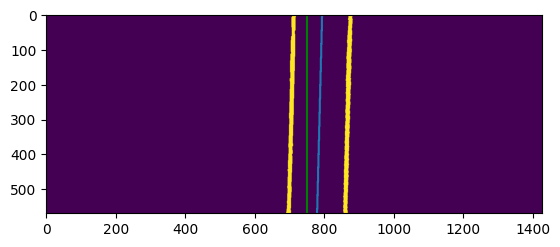

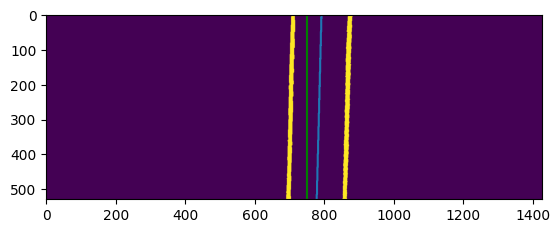

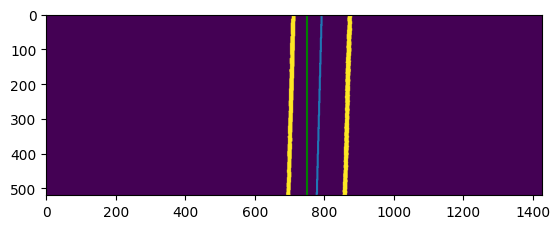

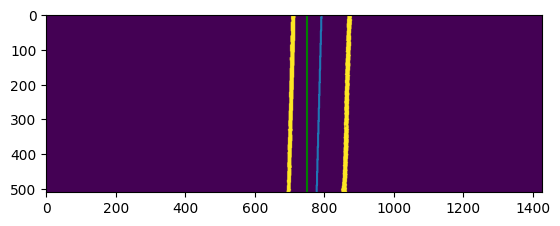

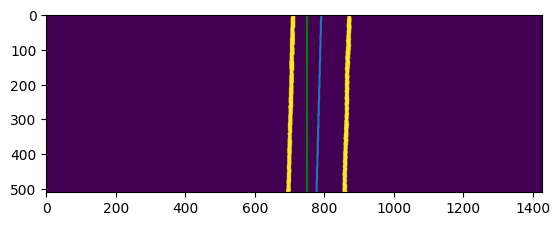

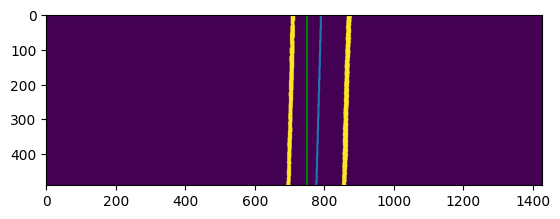

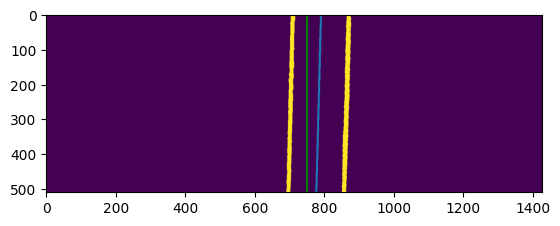

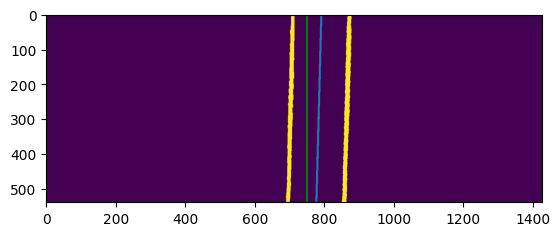

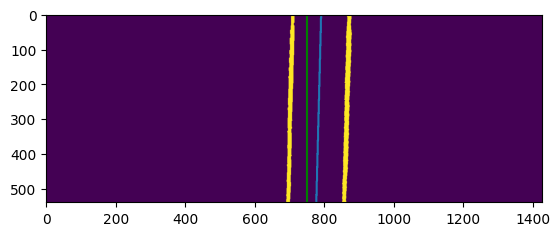

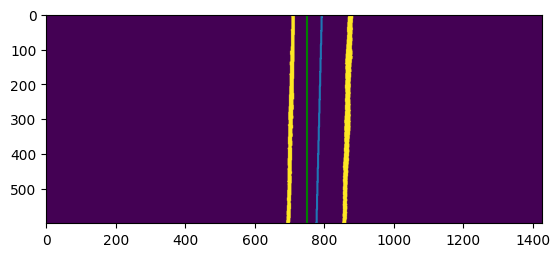

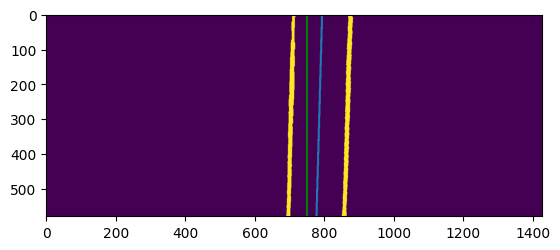

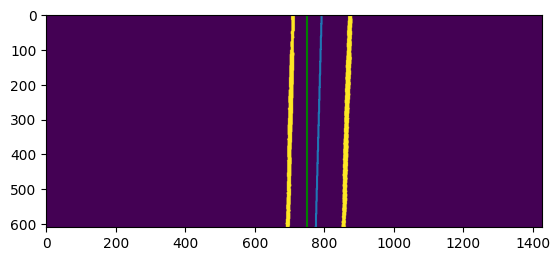

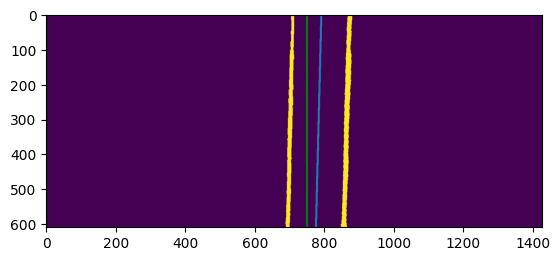

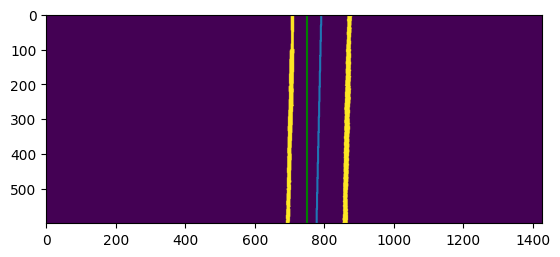

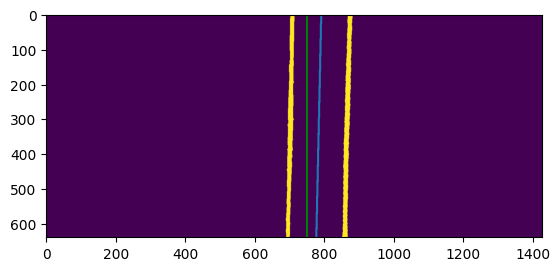

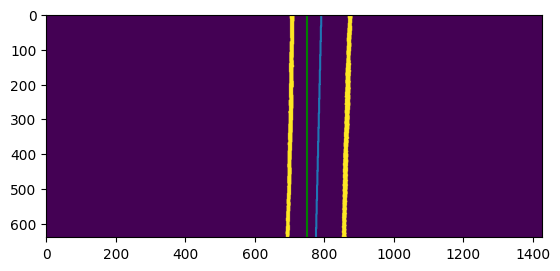

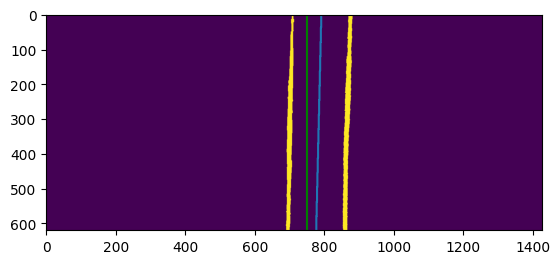

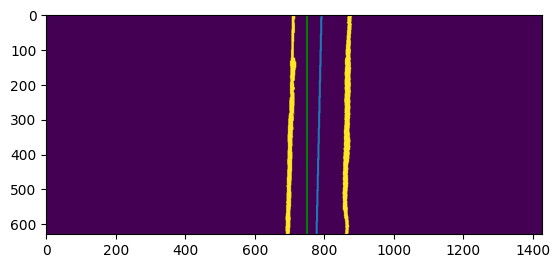

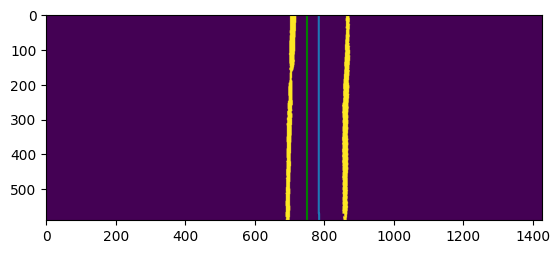

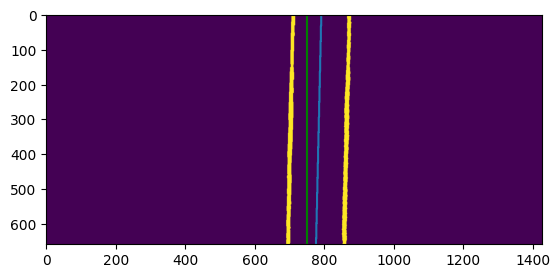

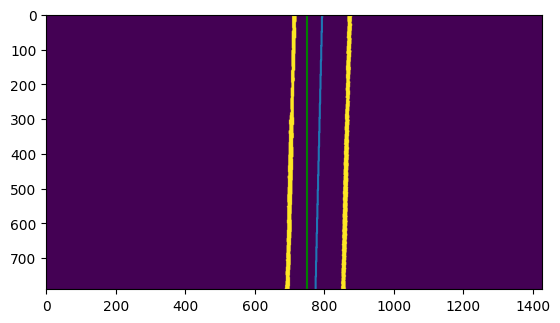

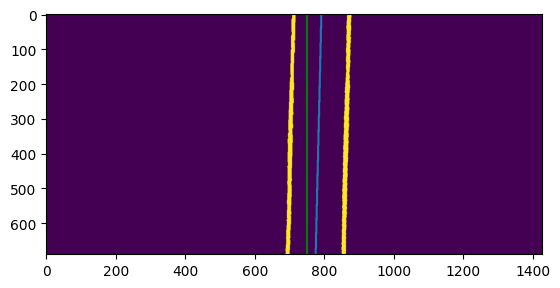

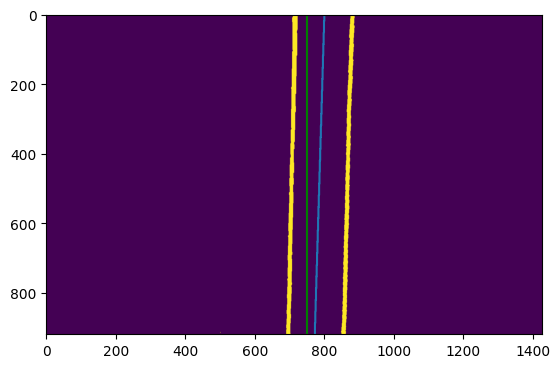

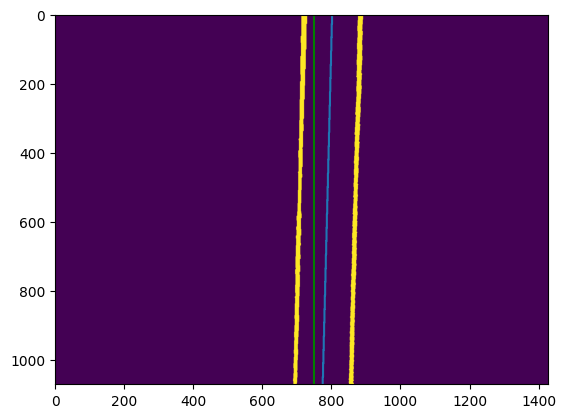

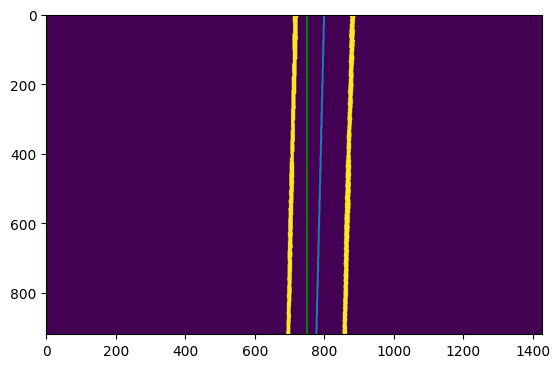

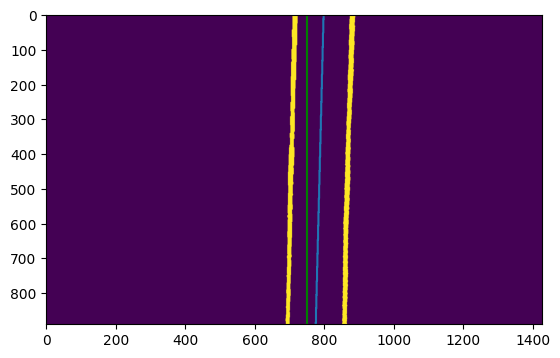

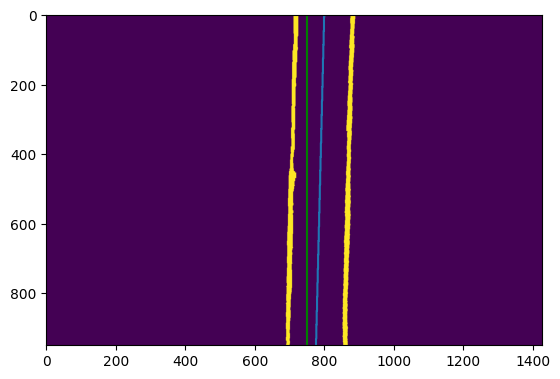

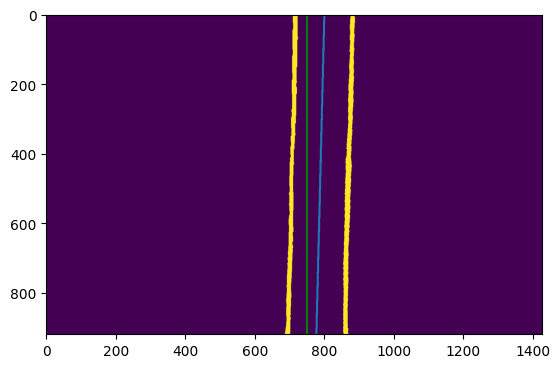

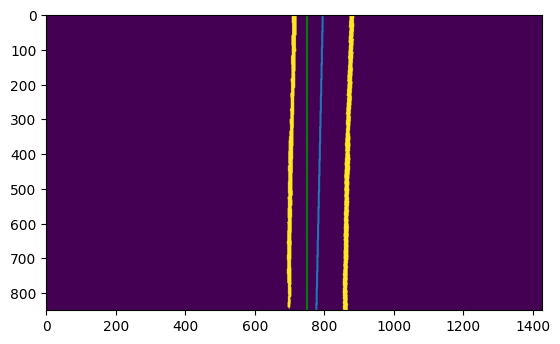

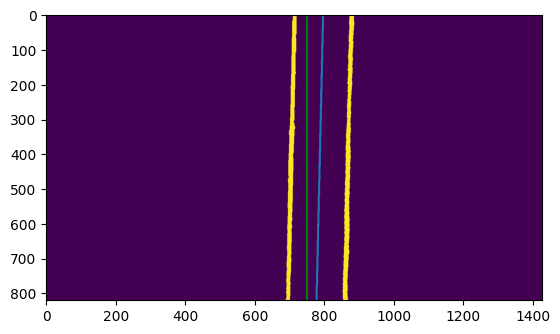

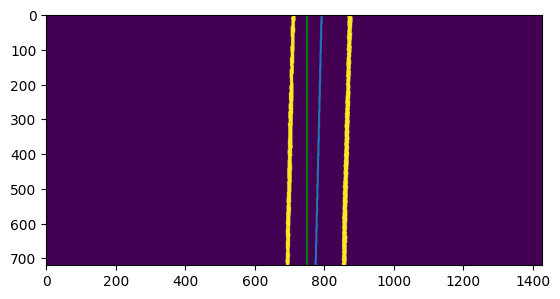

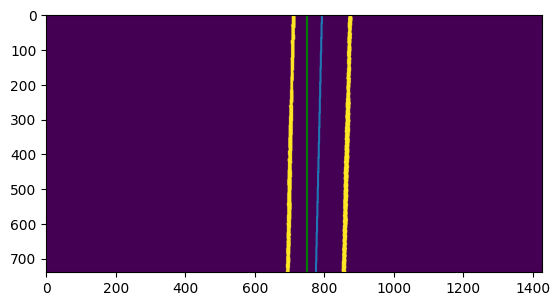

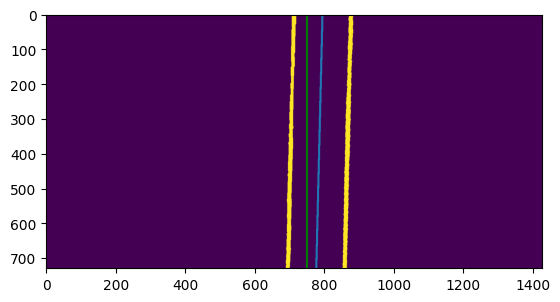

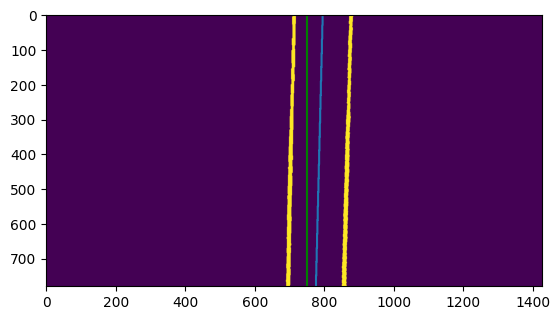

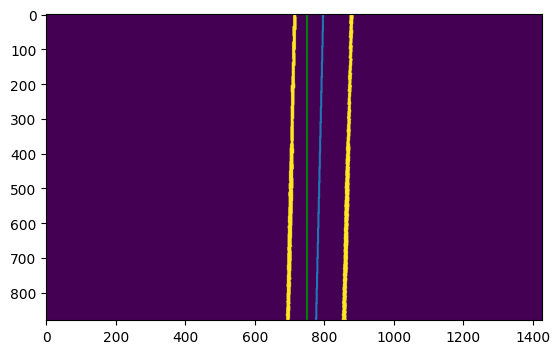

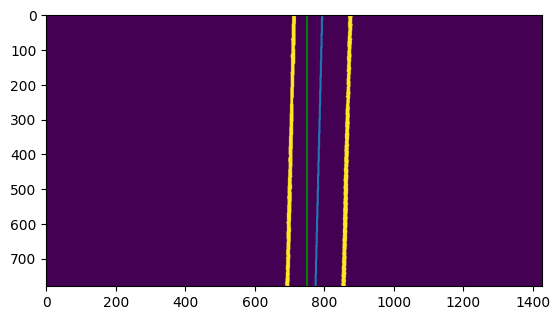

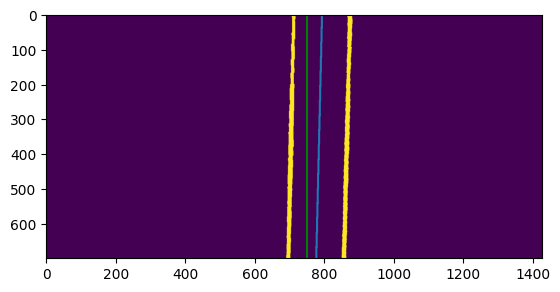

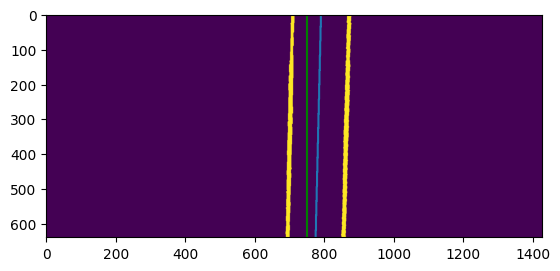

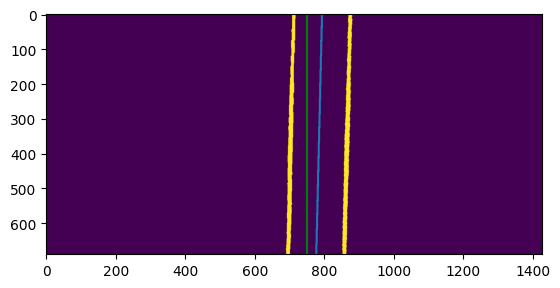

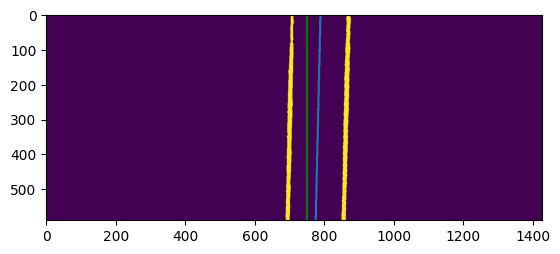

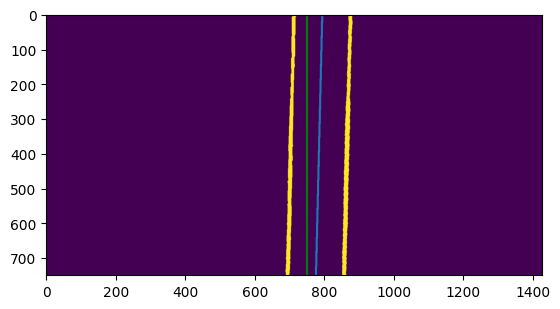

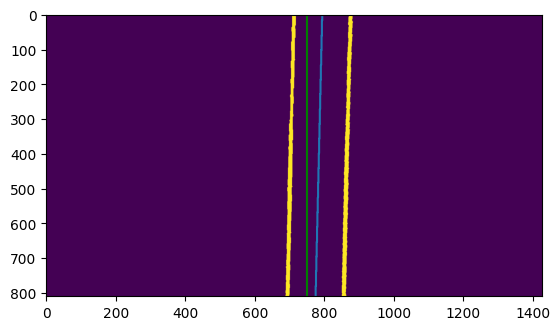

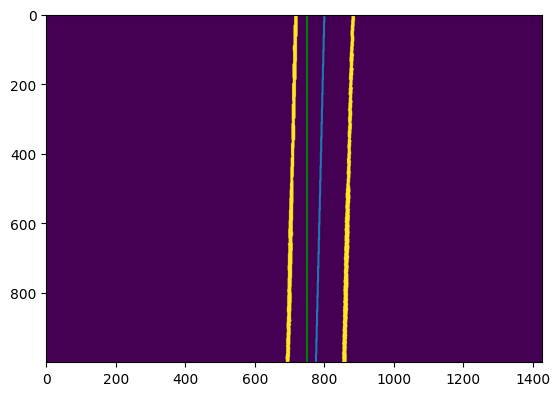

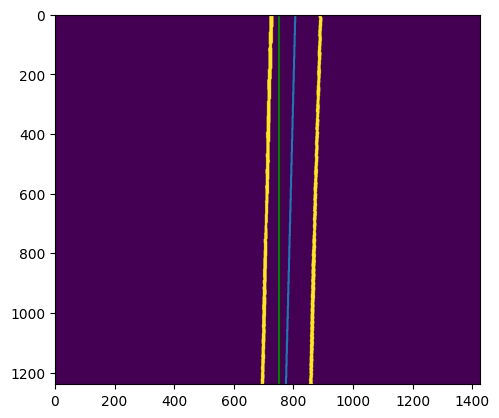

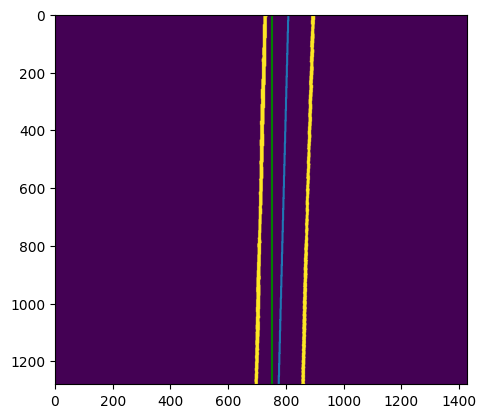

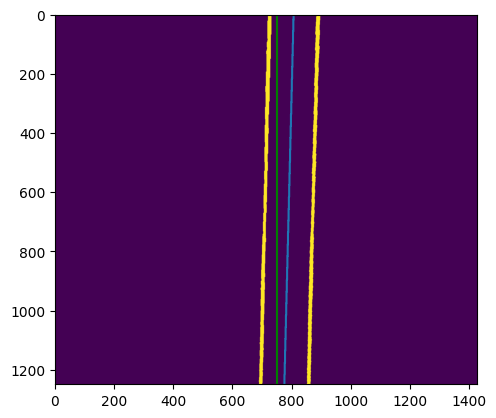

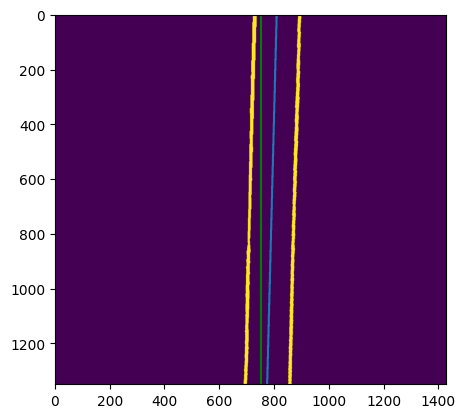

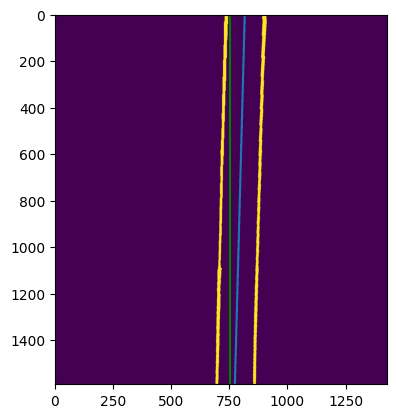

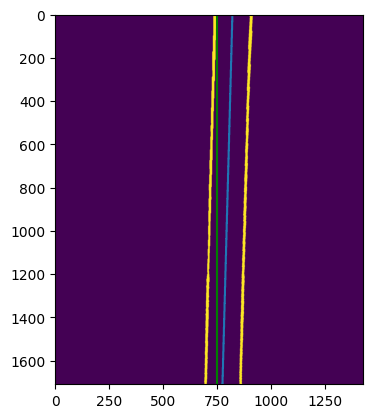

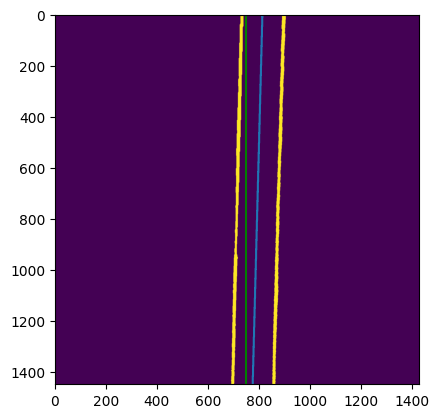

In [54]:
Array = np.zeros((1, 2))
angle_all = np.zeros((1))

angle = 0
coef = 0
shift = 0
for i, (m_f, c) in enumerate(zip(msk_fs[0:100], coord[0:100])):  # 0:-1 0:2 13:14 20:22 20:32 29:32
    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-(coord[i+1] - coord[i]): mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)

    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================

    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================
    plt.imshow(resize(mask))
    plt.plot(yx_centr[:, 1]//10, yx_centr[:, 0][::-1]//10)
    plt.axvline((mask.shape[1] // 20)+38, c='g')
    plt.show()

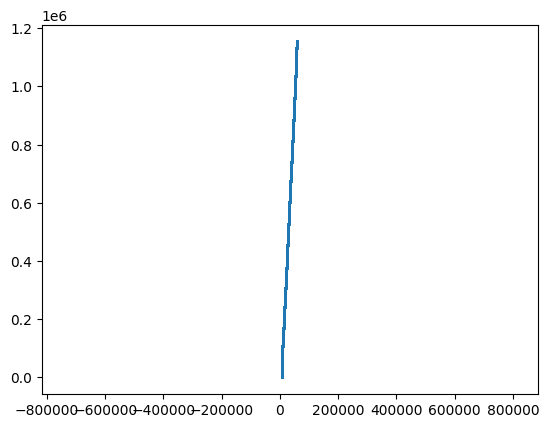

In [1054]:
# накапливать разницу углов в каждом кадре, на неё поворачивать
# yx_centr низ [-1], верх [0]

Array = np.zeros((1, 2))
angle_all = np.zeros((1))

x_norm = 7513

coef = 0.0
for i, (m_f, c) in enumerate(zip(msk_fs[0:-1], coord[0:-1])):  # 0:-1 0:2 13:14 20:22 20:32 29:32
    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-(coord[i+1] - coord[i]): mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)

    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================
    # plt.imshow(resize(mask))
    # plt.plot(yx_centr[:, 1]//10, yx_centr[:, 0][::-1]//10)
    # plt.axvline((mask.shape[1] // 20)+38, c='g')
    # plt.show()
    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================

    # текущий угол
    p1 = yx_centr[-1][::-1]
    p2 = yx_centr[0][::-1]
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    curr_angle = np.arctan2(dx, dy)
    # print('curr_angl', curr_angle)
    # print('p1', p1)
    # print('p2', p2)

    if i > 0:
        # смещение по У
        yx_centr[:, 0] += coef

        delta = curr_angle - prev_angle
        # print('delta', delta)
        angle += delta
        # print('angle', angle)

        # смещение по X
        shift = a - yx_centr[-1, 1]
        yx_centr[:, 1] += shift

        # поворот
        yx_centr = rotate(yx_centr[:, [1, 0]], -angle, yx_centr[-1, [1, 0]])[:, [1, 0]]
    else:
        angle = 0.0

    prev_angle = curr_angle
    # для смещения по Х
    a = yx_centr[0, 1]
    # обновл коорд Y на пройденный путь
    coef += yx_centr[0, 0] - yx_centr[-1, 0]  # shape тут не подходит, т.к. не измен после поворота


    Array = np.vstack((Array, yx_centr))
Array = Array[1:, :]  # убир перв строка, кот 0 0
plt.scatter(Array[:, 1], Array[:, 0], s=1)
plt.axis('equal')
plt.show()

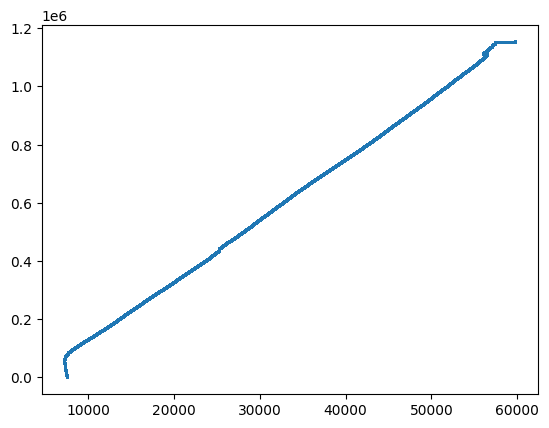

In [1055]:
plt.scatter(Array[:, 1], Array[:, 0], s=1)
# plt.axis('equal')
plt.show()

(np.float64(-26472.037483663233),
 np.float64(700159.4230200489),
 np.float64(-59820.119164913136),
 np.float64(375277.1422979859))

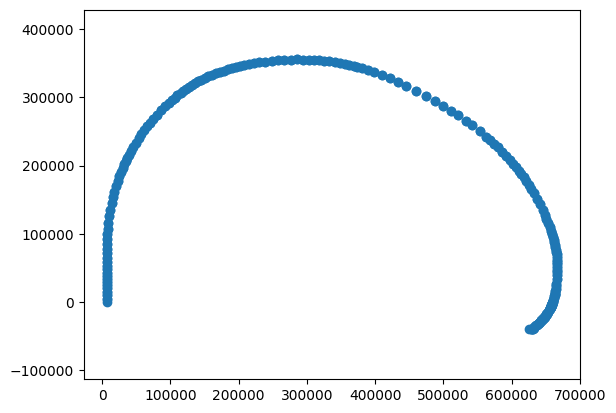

In [ ]:
# нов

coords = []

for i, (m_f, c) in enumerate(zip(msk_fs[0:-1], coord[0:-1])):  # 0:-1 0:2 13:14 20:22 20:32 29:32 80:90
    # пройденный путь до след коорд
    L = (coord[i+1] - coord[i])

    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-L: mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)
    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================

    # угол наклона пути
    p1 = yx_centr[-1][::-1]
    p2 = yx_centr[0][::-1]
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    alpha_curr = np.arctan2(dx, dy)
    # print(alpha_curr)

    # ================================
    # найти след точку с учетом предыдущ
    if i > 0:
        p1 = p2_real
        # delta =  alpha_curr - alpha_prev
        # alpha_curr += delta

        alpha_curr += alpha_prev
    # ================================

    # найти след точку в сист коорд
    unit_vector = np.array([np.sin(alpha_curr), np.cos(alpha_curr)])
    p2_real = p1 + L * unit_vector

    alpha_prev = alpha_curr

    coords.append([p1, p2_real])
coords = np.vstack(coords)
plt.scatter(coords[:, 0], coords[:, 1])
plt.axis('equal')


In [ ]:
# по дельта Х
x_norm = 7513
coords = []

for i, (m_f, c) in enumerate(zip(msk_fs[0:30], coord[0:30])):  # 0:-1 0:2 13:14 20:22 20:32 29:32 80:90
    # пройденный путь до след коорд
    L = (coord[i+1] - coord[i])

    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-L: mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)
    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================

    if i > 0:
        dx2 = yx_centr[-1, 1] - x_norm
        print(dx2 - dx1)
        dx1 = dx2
    else:
        dx1 = yx_centr[-1, 1] - x_norm


-7.034016389739918
-10.249984408020282
2.218632718184381
-3.8360338173970376
-0.6067360725592152
15.673930283196569
10.120226502543119
5.209441317480923
-0.2983424039111924
-10.31713466904148
7.952086944397706
24.55320095908246
26.719757704579933
50.91920570328875
23.570494015218173
81.81896557449636
24.94838286367758
18.955455037032152
-1.5316414006665582
8.1147280616442
-0.22000970633325778
-2.592149121241164
5.126184716114949
-7.561437794282028
4.624704754402956
-5.138478412190125
4.220055180820054
8.448420701109171
-0.9159859673118262
